# Altis App Forecast Reproduction & Evidence Notebook

This notebook is an analyst evidence pack for the live app dashboards.

It reproduces the current app calculation path:

```text
raw Excel files
→ pipeline/ingest.py normalized SQLite tables
→ weekly_financials + weather_weekly + assumptions + covenants
→ same forecast logic as lib/forecast/engine.ts
→ dashboard KPIs, cash charts, driver decomposition, covenant headroom, trace evidence
```

The point is not to build a second model. The point is to prove how the app's CFO/Board/Opco/Project numbers are populated, using auditable Python cells that analysts can tweak.

## 0. Setup

Beginner explanation: load Python packages, local paths, and helper functions.

Technical explanation: all source-of-truth values are read from `data/altis.db`, which is created by the app pipeline. Optional API comparison calls validate the notebook against the running Next.js app.

In [1]:
import os
from pathlib import Path
import json
import sqlite3
import urllib.request
import urllib.error

os.environ.setdefault("MPLCONFIGDIR", "/private/tmp/matplotlib-altis")
Path(os.environ["MPLCONFIGDIR"]).mkdir(parents=True, exist_ok=True)

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

def find_project_root():
    """Find the repo even when this notebook is opened from Downloads/Jupyter home."""
    candidates = []
    env_root = os.environ.get("ALTIS_PROJECT_ROOT")
    if env_root:
        candidates.append(Path(env_root).expanduser())
    cwd = Path.cwd().resolve()
    candidates.extend([cwd, *cwd.parents])
    candidates.extend([
        Path("/Users/priyanjaligoel/Documents/paper_2_architecture/altis-weather-cashflow"),
        Path.home() / "Documents/paper_2_architecture/altis-weather-cashflow",
    ])
    for c in candidates:
        if (c / "data" / "altis.db").exists() and (c / "data" / "raw").exists():
            return c.resolve()
    raise FileNotFoundError(
        "Could not find Altis project root. Set ALTIS_PROJECT_ROOT to the repo path, "
        "for example: /Users/priyanjaligoel/Documents/paper_2_architecture/altis-weather-cashflow"
    )

ROOT = find_project_root()

DB = ROOT / "data" / "altis.db"
RAW = ROOT / "data" / "raw"
ART = ROOT / "data" / "artifacts"
APP_BASE_URL = "http://localhost:3001"

plt.rcParams.update({
    "figure.figsize": (12, 5),
    "axes.grid": True,
    "grid.alpha": 0.25,
    "font.size": 10,
})

def q(sql, params=None):
    with sqlite3.connect(f"file:{DB}?mode=ro", uri=True) as conn:
        return pd.read_sql_query(sql, conn, params=params or {})

def eur(x):
    if pd.isna(x):
        return "–"
    return f"€{x:,.0f}"

def eur_axis(ax):
    ax.get_yaxis().set_major_formatter(lambda x, pos: f"€{x/1_000_000:.1f}M")

def eur_smart_axis(ax):
    ymin, ymax = ax.get_ylim()
    max_abs = max(abs(ymin), abs(ymax))
    if max_abs >= 1_000_000:
        ax.get_yaxis().set_major_formatter(lambda x, pos: f"€{x/1_000_000:.1f}M")
    elif max_abs >= 1_000:
        ax.get_yaxis().set_major_formatter(lambda x, pos: f"€{x/1_000:.0f}k")
    else:
        ax.get_yaxis().set_major_formatter(lambda x, pos: f"€{x:,.0f}")

def week_start(d):
    d = pd.Timestamp(d)
    return (d - pd.Timedelta(days=d.weekday())).strftime("%Y-%m-%d")

def add_weeks_key(key, n):
    return (pd.Timestamp(key) + pd.Timedelta(weeks=n)).strftime("%Y-%m-%d")

def iso_week(key):
    return int(pd.Timestamp(key).isocalendar().week)

print("Project root:", ROOT)
print("SQLite DB:", DB)
print("Raw data folder:", RAW)

Project root: /Users/priyanjaligoel/Documents/paper_2_architecture/altis-weather-cashflow
SQLite DB: /Users/priyanjaligoel/Documents/paper_2_architecture/altis-weather-cashflow/data/altis.db
Raw data folder: /Users/priyanjaligoel/Documents/paper_2_architecture/altis-weather-cashflow/data/raw


## 1. Raw Excel Evidence

Beginner explanation: before trusting a forecast, check what files were supplied and what their sheets/columns look like.

Technical explanation: this inspects the raw Excel workbooks directly. The app itself uses the pipeline to normalize these into SQLite; this section proves the workbook-level source evidence exists.

In [2]:
excel_files = sorted(list((RAW / "portfolio company data").glob("*.xlsx")) +
                     list((RAW / "portfolio company 2 data").glob("*.xlsx")) +
                     list((RAW / "datasets").glob("*.xlsx")))

raw_rows = []
for p in excel_files:
    try:
        xl = pd.ExcelFile(p)
        for sheet in xl.sheet_names:
            preview = pd.read_excel(p, sheet_name=sheet, nrows=5)
            raw_rows.append({
                "file": p.name,
                "folder": p.parent.name,
                "sheet": sheet,
                "columns": ", ".join(map(str, preview.columns[:8])),
                "preview_rows": len(preview),
            })
    except Exception as e:
        raw_rows.append({"file": p.name, "folder": p.parent.name, "sheet": "ERROR", "columns": str(e), "preview_rows": 0})

raw_inventory = pd.DataFrame(raw_rows)
display(raw_inventory.head(30))
print(f"Raw Excel files inspected: {len(excel_files)}")

,file,folder,sheet,columns,preview_rows
0,Altis dataset 1.xlsx,datasets,2023,"Unnamed: 0, Jan, Feb, Mrt, Apr, Mei, Jun, Jul",3
1,Altis dataset 1.xlsx,datasets,2024,"Unnamed: 0, Jan, Feb, Mrt, Apr, Mei, Jun, Jul",3
2,Altis dataset 1.xlsx,datasets,2025,"Unnamed: 0, Jan, Feb, Mrt, Apr, Mei, Jun, Jul",3
3,Altis dataset 1.xlsx,datasets,2026YTD,"Unnamed: 0, Jan, Feb, Mrt, Apr, Mei, Unnamed: ...",3
4,Altis dataset 2.xlsx,datasets,Totaal,"2023-01-31 00:00:00, 2023-02-28 00:00:00, 2023...",4
5,Altis dataset 2.xlsx,datasets,2023,"Datum, Bkst.nr., Dagboek, Debet, Credit, Btw-b...",5
6,Altis dataset 2.xlsx,datasets,2024,"Datum, Bkst.nr., Dagboek, Debet, Credit, Btw-b...",5
7,Altis dataset 2.xlsx,datasets,2025,"Datum, Bkst.nr., Dagboek, Debet, Credit, Btw-b...",5
8,Altis dataset 2.xlsx,datasets,2026,"Datum, Bkst.nr., Dagboek, Debet, Credit, Btw-b...",5
9,Altis dataset 2.xlsx,datasets,Company E 2026,"Factuurdatum, Unnamed: 1, Factuurnummer, Unnam...",5


Raw Excel files inspected: 22


## 2. App Data Model: Tables Feeding The Dashboards

Beginner explanation: the app does not read every Excel file directly on page load. It reads normalized tables.

Technical explanation: `/api/forecast` pulls `companies`, `weekly_financials`, `weather_weekly`, and `covenants`; traceability also uses `transactions`.

In [3]:
companies = q("select * from companies order by id")
weekly = q("select * from weekly_financials order by company_id, week_start")
weather = q("select * from weather_weekly order by location_id, week_start")
covenants = q("select * from covenants order by id")
transactions = q("select * from transactions")
source_files = q("select * from source_files")
accounts = q("select * from accounts")

display(companies[["id", "code", "short_name", "source_system", "source_confidence", "weather_location_id"]])

table_counts = pd.DataFrame([
    {"table": "companies", "rows": len(companies)},
    {"table": "weekly_financials", "rows": len(weekly)},
    {"table": "weather_weekly", "rows": len(weather)},
    {"table": "covenants", "rows": len(covenants)},
    {"table": "transactions", "rows": len(transactions)},
    {"table": "source_files", "rows": len(source_files)},
    {"table": "accounts", "rows": len(accounts)},
])
display(table_counts)

,id,code,short_name,source_system,source_confidence,weather_location_id
0,1,ummels,Peter Ummels,Snelstart / FinTransactions export,high,1
1,2,opco-a,Opco A,Exact-style general-ledger export,medium,2
2,3,opco-gilde,Opco C,Gilde (Verkoopboek Gilde),medium,2
3,4,opco-e,Company E,Invoice register,low,2


,table,rows
0,companies,4
1,weekly_financials,523
2,weather_weekly,364
3,covenants,4
4,transactions,32278
5,source_files,26
6,accounts,11


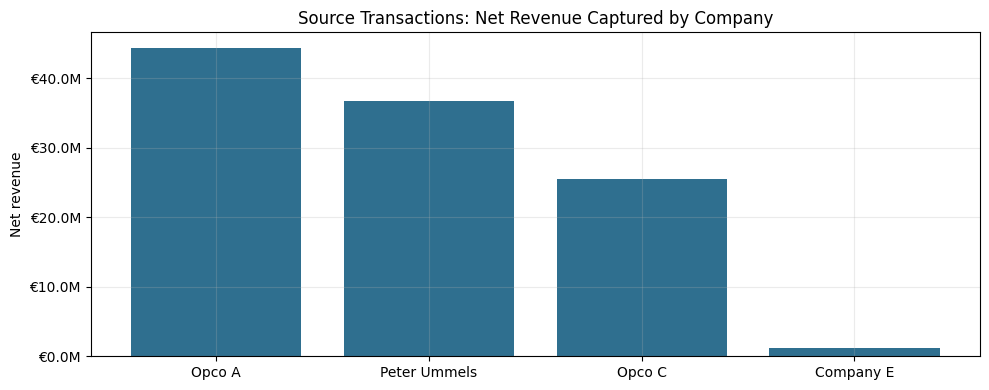

,short_name,transactions,net_revenue
1,Opco A,9673,44403030.77
3,Peter Ummels,9958,36668632.17
2,Opco C,12318,25466016.65
0,Company E,329,1171252.08


In [4]:
fig, ax = plt.subplots(figsize=(10, 4))
tx_by_company = transactions.merge(companies[["id", "short_name"]], left_on="company_id", right_on="id")
tx_summary = tx_by_company.groupby("short_name").agg(
    transactions=("id_x", "count"),
    net_revenue=("amount_net", "sum"),
).reset_index().sort_values("net_revenue", ascending=False)
ax.bar(tx_summary["short_name"], tx_summary["net_revenue"], color="#2f6f8f")
eur_axis(ax)
ax.set_title("Source Transactions: Net Revenue Captured by Company")
ax.set_ylabel("Net revenue")
plt.tight_layout()
plt.show()
display(tx_summary)

## 3. Weekly Revenue and Seasonality

Beginner explanation: before the app forecasts cash, it needs to understand normal billing rhythm. These charts show historical weekly billing, the robust 8-week rolling median baseline, and the ISO-week seasonal billing profile.

Technical explanation: weekly `credit_total` approximates gross billing/facturation. The 8-week rolling median smooths invoice spikes. The seasonal profile groups billing by ISO week number so a future week can be compared with historically similar calendar weeks.

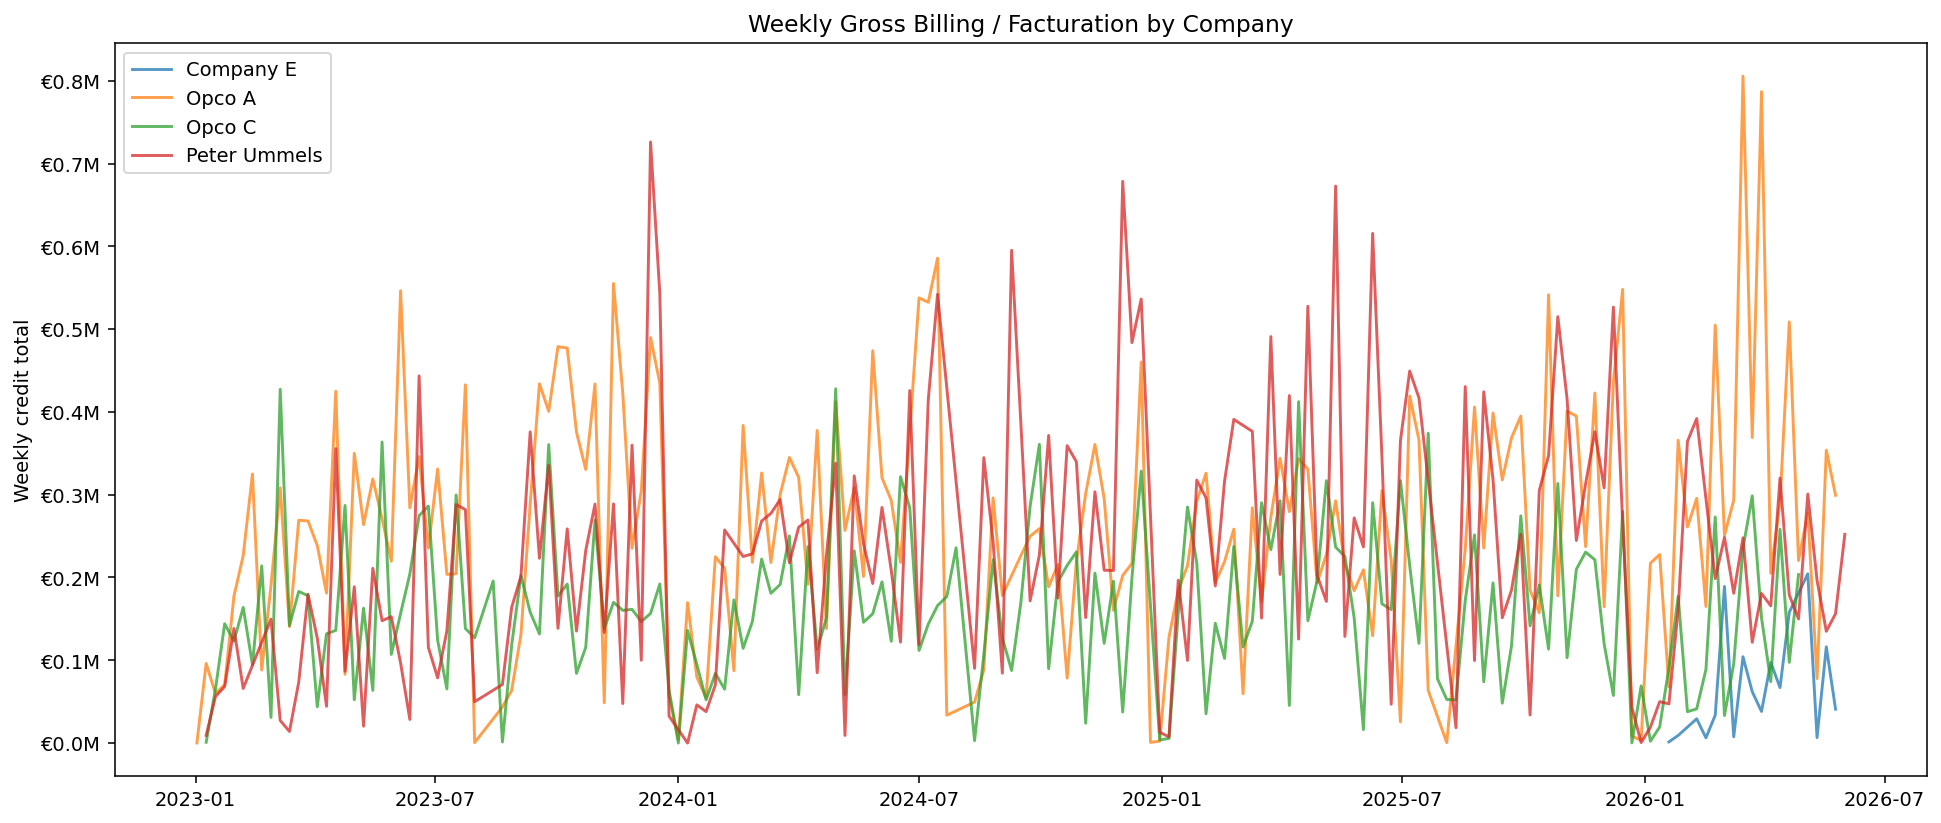

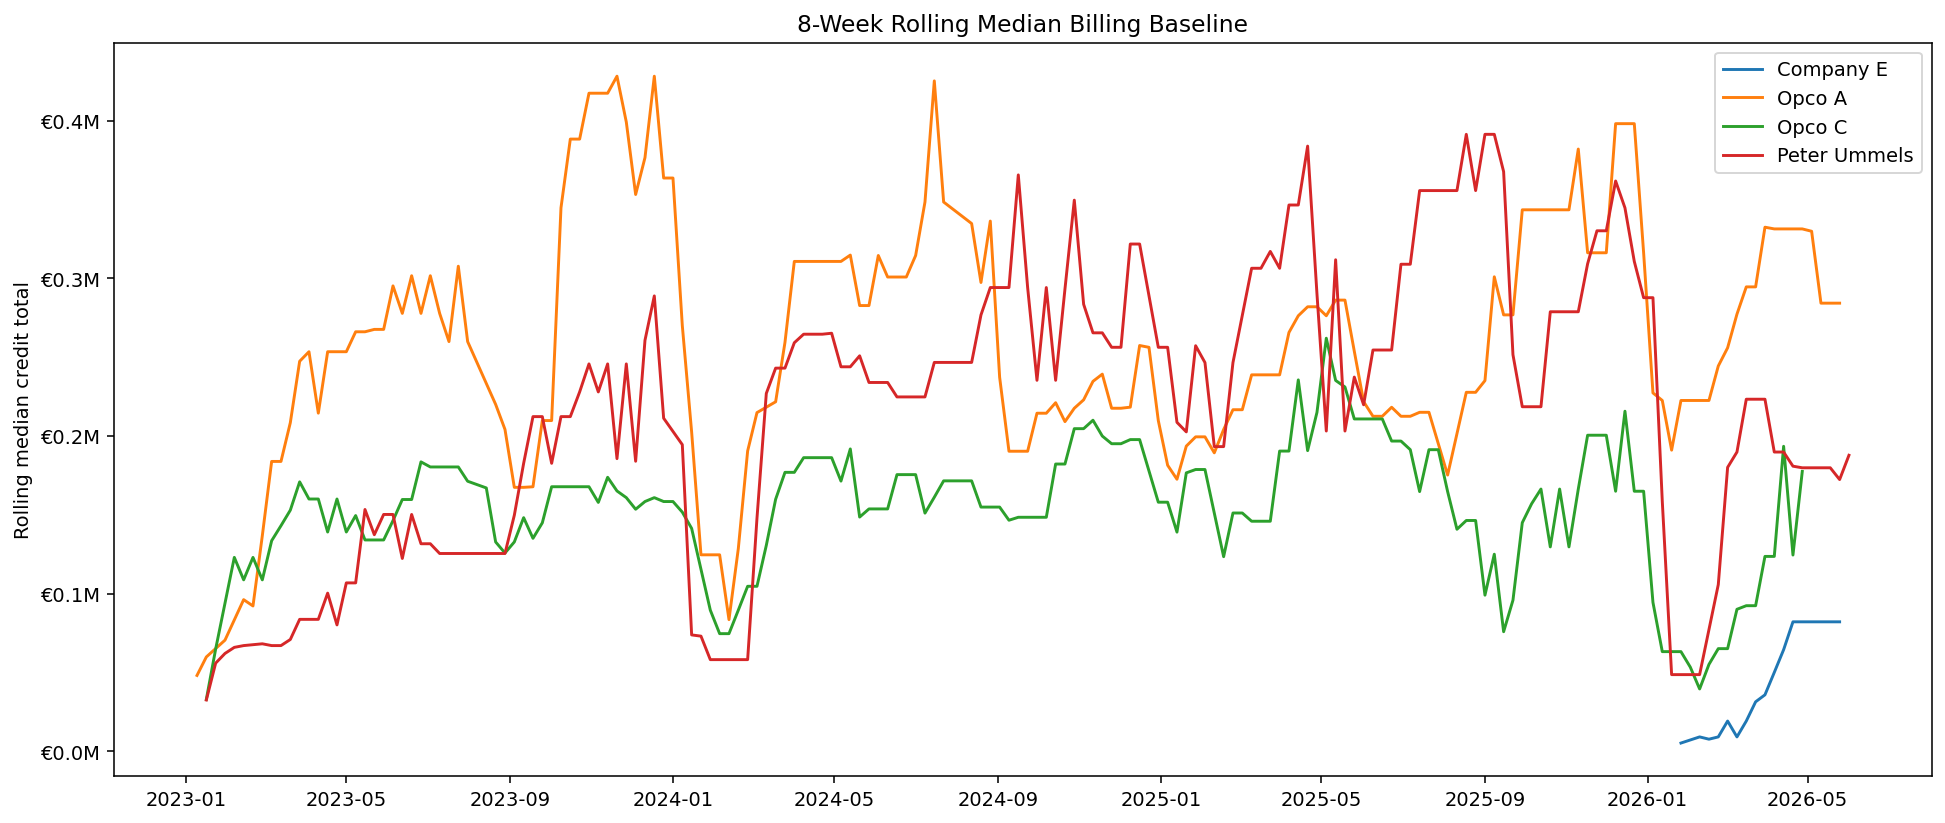

short_name,weeks,first_week,last_week,median_weekly_billing,latest_8w_median
Company E,17,2026-01-19,2026-05-25,40890.690,82151.36
Opco A,172,2023-01-02,2026-05-25,253837.830,284194.17
Opco C,170,2023-01-09,2026-04-27,153859.515,124492.24
Peter Ummels,164,2023-01-09,2026-06-01,208727.825,172354.49


In [9]:
weekly_seasonality = weekly.merge(
    companies[["id", "short_name"]],
    left_on="company_id",
    right_on="id",
    how="left",
).copy()
weekly_seasonality["week_start"] = pd.to_datetime(weekly_seasonality["week_start"])

fig, ax = plt.subplots(figsize=(14, 6))
for name, g in weekly_seasonality.groupby("short_name"):
    gg = g.sort_values("week_start")
    ax.plot(gg["week_start"], gg["credit_total"], label=name, alpha=0.75)
eur_axis(ax)
ax.set_title("Weekly Gross Billing / Facturation by Company")
ax.set_ylabel("Weekly credit total")
ax.legend()
plt.tight_layout()
plt.show()

fig, ax = plt.subplots(figsize=(14, 6))
for name, g in weekly_seasonality.groupby("short_name"):
    gg = g.sort_values("week_start").copy()
    gg["rolling_median_8w"] = gg["credit_total"].rolling(8, min_periods=2).median()
    ax.plot(gg["week_start"], gg["rolling_median_8w"], label=name)
eur_axis(ax)
ax.set_title("8-Week Rolling Median Billing Baseline")
ax.set_ylabel("Rolling median credit total")
ax.legend()
plt.tight_layout()
plt.show()

display(
    weekly_seasonality
    .groupby("short_name")
    .agg(
        weeks=("week_start", "count"),
        first_week=("week_start", "min"),
        last_week=("week_start", "max"),
        median_weekly_billing=("credit_total", "median"),
        latest_8w_median=("baseline_credit", "last"),
    )
    .reset_index()
)

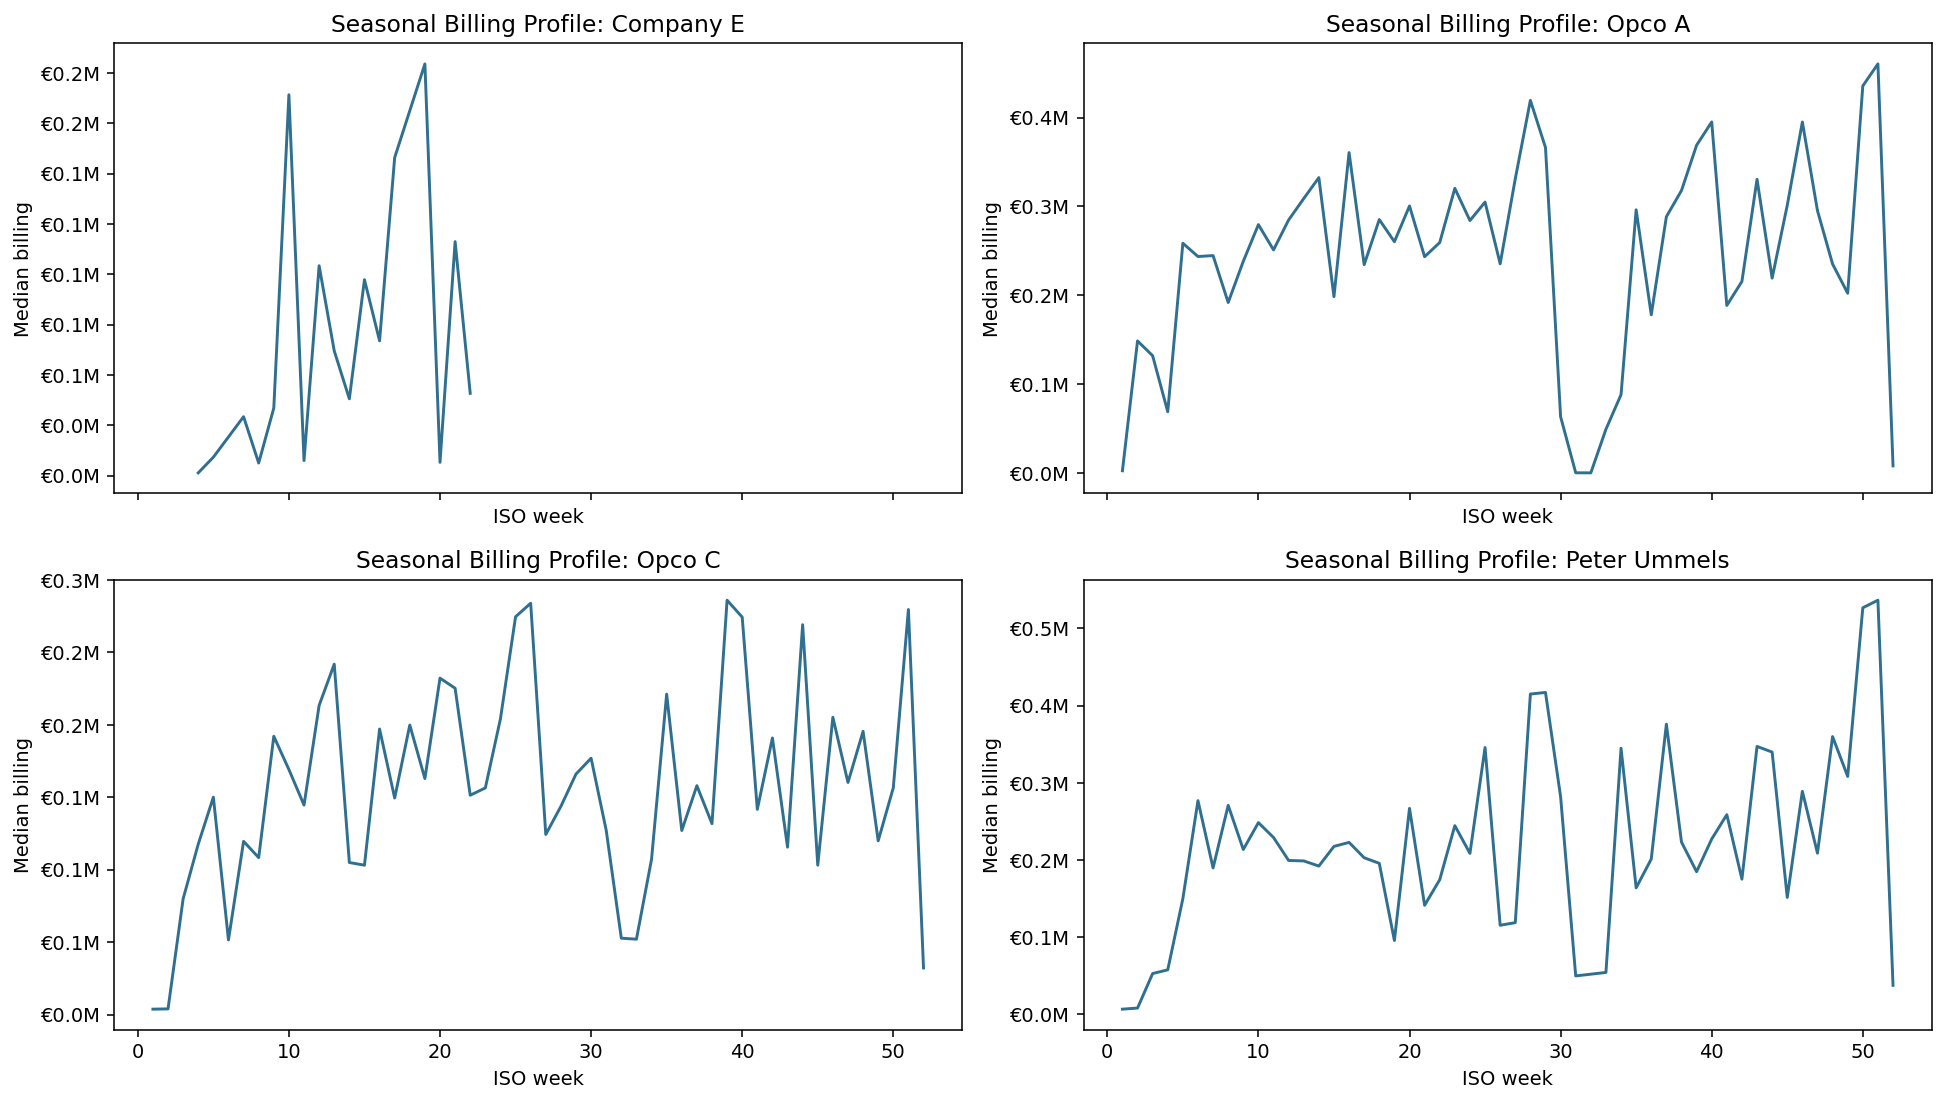

short_name,iso_week,credit_total
Company E,4,1398.950
Company E,5,9186.310
Company E,7,29291.770
Company E,8,6292.170
Company E,9,33585.830
Company E,10,189141.240
Company E,11,7505.390
Company E,12,104247.360
Company E,13,61981.890
Company E,14,38161.450


In [10]:
weekly_seasonality["iso_week"] = weekly_seasonality["week_start"].dt.isocalendar().week.astype(int)
season = (
    weekly_seasonality
    .groupby(["short_name", "iso_week"])["credit_total"]
    .median()
    .reset_index()
)

fig, axes = plt.subplots(2, 2, figsize=(14, 8), sharex=True)
axes = axes.ravel()
for ax, (name, g) in zip(axes, season.groupby("short_name")):
    ax.plot(g["iso_week"], g["credit_total"], color="#2f6f8f")
    eur_axis(ax)
    ax.set_title(f"Seasonal Billing Profile: {name}")
    ax.set_xlabel("ISO week")
    ax.set_ylabel("Median billing")
for ax in axes[len(season["short_name"].unique()):]:
    ax.axis("off")
plt.tight_layout()
plt.show()

display(season.head(20))

## 4. Current App Forecast Parameters

These constants mirror `lib/forecast/config.ts`. Analysts can tweak them here to see how dashboard outputs move.

In [5]:
SCENARIOS = ["base", "wet_quarter", "dry_quarter"]
SCENARIO_LABELS = {
    "base": "Live forecast",
    "wet_quarter": "Wet sensitivity",
    "dry_quarter": "Dry sensitivity",
}
SCENARIO_WEATHER_INTENSITY = {
    "base": 1.0,
    "wet_quarter": 1.5,
    "dry_quarter": 0.5,
}
OPENING_CASH = {
    "ummels": 600000,
    "opco-a": 900000,
    "opco-gilde": 200000,
    "opco-e": 120000,
}
DEFAULT_OPENING_CASH = 300000

DEFAULT_PARAMS = {
    "horizonWeeks": 13,
    "drivers": {"materials": 0.32, "subcontractor": 0.18, "labour": 0.22, "overhead": 0.10},
    "driverLagWeeks": {"materials": 2, "subcontractor": 3, "labour": 0, "overhead": 0},
    "paymentLagWeights": [0, 0, 0.10, 0.20, 0.30, 0.20, 0.12, 0.05, 0.03],
    "weatherShiftHigh": 0.25,
    "weatherShiftMedium": 0.12,
    "catchUpStartLag": 4,
    "catchUpWeights": [0.30, 0.25, 0.25, 0.20],
    "baselineLookbackWeeks": 8,
}

params_table = []
for k, v in DEFAULT_PARAMS.items():
    params_table.append({"parameter": k, "value": str(v)})
params_table += [{"parameter": f"openingCash.{k}", "value": v} for k, v in OPENING_CASH.items()]
params_table += [{"parameter": f"weatherIntensity.{k}", "value": v} for k, v in SCENARIO_WEATHER_INTENSITY.items()]
display(pd.DataFrame(params_table))

,parameter,value
0,horizonWeeks,13
1,drivers,"{'materials': 0.32, 'subcontractor': 0.18, 'la..."
2,driverLagWeeks,"{'materials': 2, 'subcontractor': 3, 'labour':..."
3,paymentLagWeights,"[0, 0, 0.1, 0.2, 0.3, 0.2, 0.12, 0.05, 0.03]"
4,weatherShiftHigh,0.25
5,weatherShiftMedium,0.12
6,catchUpStartLag,4
7,catchUpWeights,"[0.3, 0.25, 0.25, 0.2]"
8,baselineLookbackWeeks,8
9,openingCash.ummels,600000


## 5. Python Reproduction of `computeCompanyForecast`

Beginner explanation: this is the same calculation the app uses, written in Python so analysts can inspect each step.

Technical explanation: mirrors `buildSeasonalProfile`, `buildWeatherSeries`, and `computeCompanyForecast`.

In [6]:
def mean(xs):
    xs = list(xs)
    return sum(xs) / len(xs) if xs else 0

def median(xs):
    xs = sorted(list(xs))
    if not xs:
        return 0
    m = len(xs) // 2
    return xs[m] if len(xs) % 2 else (xs[m-1] + xs[m]) / 2

def clamp(x, lo, hi):
    return max(lo, min(hi, x))

def classify_risk(rain_workdays):
    if rain_workdays >= 2.5:
        return "high"
    if rain_workdays >= 1.5:
        return "medium"
    return "low"

def build_seasonal_profile(history, lookback):
    hist = history.copy().sort_values("week_start")
    prod = pd.DataFrame({
        "week": hist["week_start"],
        "value": hist["credit_total"].clip(lower=0),
    })
    overall_mean = prod["value"].mean() if len(prod) else 1
    if not overall_mean:
        overall_mean = 1
    prod["iso_week"] = prod["week"].apply(iso_week)
    idx = (prod.groupby("iso_week")["value"].mean() / overall_mean).clip(0.25, 2.5).to_dict()
    def seasonal_index(woy):
        return float(idx.get(int(woy), 1.0))
    recent = prod.tail(lookback).copy()
    deseason = [row.value / seasonal_index(row.iso_week) for row in recent.itertuples()]
    level = median(deseason) or overall_mean
    actual = dict(zip(prod["week"], prod["value"]))
    return {"level": level, "seasonal_index": seasonal_index, "actual": actual, "overall_mean": overall_mean}

def build_weather_series(weather_hist, start_week, horizon, intensity):
    wh = weather_hist.copy().sort_values("week_start")
    live = {r.week_start: r for r in wh[wh["is_forecast"] == 1].itertuples()}
    hist = wh[wh["is_forecast"] == 0].copy()
    hist["iso_week"] = hist["week_start"].apply(iso_week)
    clim_rain = hist.groupby("iso_week")["rain_days_2mm"].mean().to_dict()
    clim_score = hist.groupby("iso_week")["delay_score"].mean().to_dict()
    clim_bad = hist.groupby("iso_week")["bad_workdays"].mean().to_dict()
    items = []
    for i in range(horizon):
        wk = add_weeks_key(start_week, i)
        woy = iso_week(wk)
        if wk in live:
            lv = live[wk]
            rain_wd = lv.rain_days_2mm
            score = lv.delay_score
            bad = lv.bad_workdays
            is_live = True
            source = "live-forecast"
            f = 1.0
        else:
            rain_wd = clim_rain.get(woy, 0)
            score = clim_score.get(woy, 0)
            bad = clim_bad.get(woy, 0)
            is_live = False
            source = "seasonal"
            f = intensity
        rain_wd *= f
        score *= f
        bad *= f
        items.append({
            "weekStart": wk,
            "weekIndex": i + 1,
            "isLiveWeather": is_live,
            "weatherSource": source,
            "expectedRainWorkdays": round(rain_wd, 1),
            "delayScore": round(score, 1),
            "badWorkdays": round(bad, 1),
            "weatherRisk": classify_risk(rain_wd),
        })
    return items

def resolve_params(scenario, company_code):
    p = json.loads(json.dumps(DEFAULT_PARAMS))
    p["startWeek"] = forecast_start_week
    p["openingCash"] = OPENING_CASH.get(company_code, DEFAULT_OPENING_CASH)
    p["weatherIntensity"] = SCENARIO_WEATHER_INTENSITY[scenario]
    return p

forecast_start_week = q("select min(week_start) as w from weather_weekly where is_forecast=1")["w"].iloc[0]
print("Forecast start week used by the app:", forecast_start_week)

Forecast start week used by the app: 2026-06-01


In [7]:
def compute_company_forecast(company_code="ummels", scenario="base"):
    co = companies.loc[companies["code"] == company_code].iloc[0]
    history = weekly[weekly["company_id"] == co["id"]].sort_values("week_start").copy()
    wh = weather[weather["location_id"] == co["weather_location_id"]].sort_values("week_start").copy()
    covs = covenants[(covenants["company_id"].isna()) | (covenants["company_id"] == co["id"])].copy()
    p = resolve_params(scenario, company_code)
    H = p["horizonWeeks"]
    start = p["startWeek"]
    profile = build_seasonal_profile(history, p["baselineLookbackWeeks"])
    wx = build_weather_series(wh, start, H, p["weatherIntensity"])
    def key_of(w):
        return add_weeks_key(start, w - 1)
    def baseline_prod(w):
        k = key_of(w)
        return profile["level"] * profile["seasonal_index"](iso_week(k))
    pay_len = len(p["paymentLagWeights"]) - 1
    driver_max_lag = max(p["driverLagWeeks"].values())
    pre_lag = max(pay_len, driver_max_lag)
    catch_max = p["catchUpStartLag"] + len(p["catchUpWeights"]) - 1
    base_prod = {}
    adj_prod = {}
    for w in range(1 - pre_lag, H + catch_max + 1):
        if w <= 0:
            v = profile["actual"].get(key_of(w), baseline_prod(w))
        elif w <= H:
            v = baseline_prod(w)
        else:
            v = 0
        base_prod[w] = v
        adj_prod[w] = v
    shift_out_by_week = {}
    for item in wx:
        w = item["weekIndex"]
        share = p["weatherShiftHigh"] if item["weatherRisk"] == "high" else p["weatherShiftMedium"] if item["weatherRisk"] == "medium" else 0
        if share <= 0:
            continue
        shift_out = base_prod.get(w, 0) * share
        shift_out_by_week[w] = shift_out
        adj_prod[w] = adj_prod.get(w, 0) - shift_out
        for k, cw in enumerate(p["catchUpWeights"]):
            target = w + p["catchUpStartLag"] + k
            adj_prod[target] = adj_prod.get(target, 0) + shift_out * cw
    def cash_in(w, use_adjusted=True):
        total = 0
        for lag, weight in enumerate(p["paymentLagWeights"]):
            src = w - lag
            fact = adj_prod.get(src, 0) if use_adjusted else base_prod.get(src, 0)
            total += fact * weight
        return total
    def cash_out_drivers(w):
        out = {}
        for d, share in p["drivers"].items():
            src = w - p["driverLagWeeks"][d]
            out[d] = adj_prod.get(src, 0) * share
        return out
    cash_cov = covs[(covs["metric"] == "min_cash_balance") & (covs["company_id"] == co["id"])]
    threshold = float(cash_cov["threshold"].iloc[0]) if len(cash_cov) else np.nan
    rows = []
    closing = p["openingCash"]
    for item in wx:
        w = item["weekIndex"]
        fc_cash_in = cash_in(w, True)
        bl_cash_in = cash_in(w, False)
        drivers = cash_out_drivers(w)
        fc_cash_out = sum(drivers.values())
        net = fc_cash_in - fc_cash_out
        closing += net
        headroom = closing - threshold if not np.isnan(threshold) else np.nan
        liq_rank = 0
        if not np.isnan(headroom):
            if headroom < 0:
                liq_rank = 2
            elif headroom < 0.25 * threshold:
                liq_rank = 1
        final_rank = max(liq_rank, 1 if item["weatherRisk"] == "high" else 0)
        risk_level = ["low", "medium", "high"][final_rank]
        confidence = max(45, min(95, (88 if item["isLiveWeather"] else 70) - (8 if item["weatherRisk"] == "high" else 4 if item["weatherRisk"] == "medium" else 0) - max(0, w - 3) * 1.5))
        rows.append({
            "company_code": company_code,
            "company_name": co["short_name"],
            "scenario": scenario,
            "weekIndex": w,
            "weekStart": item["weekStart"],
            "isLiveWeather": item["isLiveWeather"],
            "weatherSource": item["weatherSource"],
            "expectedRainWorkdays": item["expectedRainWorkdays"],
            "weatherRisk": item["weatherRisk"],
            "delayScore": item["delayScore"],
            "baselineProduction": round(base_prod.get(w, 0)),
            "adjustedProduction": round(adj_prod.get(w, 0)),
            "baselineCashIn": round(bl_cash_in),
            "forecastCashIn": round(fc_cash_in),
            "forecastCashOut": round(fc_cash_out),
            "materials": round(drivers["materials"]),
            "subcontractor": round(drivers["subcontractor"]),
            "labour": round(drivers["labour"]),
            "overhead": round(drivers["overhead"]),
            "weatherAdjustment": round(fc_cash_in - bl_cash_in),
            "paymentLagAdjustment": round(fc_cash_in - adj_prod.get(w, 0)),
            "netCashFlow": round(net),
            "closingCash": round(closing),
            "covenantHeadroom": round(headroom) if not np.isnan(headroom) else np.nan,
            "riskLevel": risk_level,
            "confidence": round(confidence),
            "weatherShiftOut": round(shift_out_by_week.get(w, 0)),
        })
    out = pd.DataFrame(rows)
    kpis = {
        "totalCashIn": int(out["forecastCashIn"].sum()),
        "totalCashOut": int(out["forecastCashOut"].sum()),
        "netCashFlow": int(out["forecastCashIn"].sum() - out["forecastCashOut"].sum()),
        "minClosingCash": int(out["closingCash"].min()),
        "minClosingWeek": out.loc[out["closingCash"].idxmin(), "weekStart"],
        "endingCash": int(out["closingCash"].iloc[-1]),
        "weeksAtRisk": int((out["riskLevel"] != "low").sum()),
        "covenantBreach": bool((out["covenantHeadroom"].dropna() < 0).any()),
        "liveWeatherWeeks": int(out["isLiveWeather"].sum()),
    }
    return out, kpis

weeks_ummels, kpis_ummels = compute_company_forecast("ummels", "base")
display(weeks_ummels.head())
display(pd.DataFrame([kpis_ummels]))

,company_code,company_name,scenario,weekIndex,weekStart,isLiveWeather,weatherSource,expectedRainWorkdays,weatherRisk,delayScore,...,labour,overhead,weatherAdjustment,paymentLagAdjustment,netCashFlow,closingCash,covenantHeadroom,riskLevel,confidence,weatherShiftOut
0,ummels,Peter Ummels,base,1,2026-06-01,True,live-forecast,4.0,high,21.9,...,29369,13350,0,81966,94152,694152,444152,medium,80,44499
1,ummels,Peter Ummels,base,2,2026-06-08,True,live-forecast,0.0,low,0.8,...,51147,23249,0,-34196,49574,743725,493725,low,88,0
2,ummels,Peter Ummels,base,3,2026-06-15,True,live-forecast,0.0,low,0.0,...,54646,24839,-4450,-75005,23045,766770,516770,low,88,0
3,ummels,Peter Ummels,base,4,2026-06-22,False,seasonal,0.3,low,4.9,...,35283,16038,-8900,6590,17222,783992,533992,low,68,0
4,ummels,Peter Ummels,base,5,2026-06-29,False,seasonal,2.3,medium,9.5,...,32658,14845,-13350,29254,8866,792858,542858,low,63,18422


,totalCashIn,totalCashOut,netCashFlow,minClosingCash,minClosingWeek,endingCash,weeksAtRisk,covenantBreach,liveWeatherWeeks
0,2525358,1931752,593606,694152,2026-06-01,1193605,3,False,3


## 6. Compare Notebook Output To The Running App API

Beginner explanation: this proves the notebook is reproducing the same dashboard values.

Technical explanation: if the Next.js app is running on `localhost:3001`, this cell calls `/api/forecast` and compares week-level numbers with the Python reproduction.

In [8]:
def fetch_app_forecast(company="ummels", scenario="base"):
    url = f"{APP_BASE_URL}/api/forecast?company={company}&scenario={scenario}"
    try:
        with urllib.request.urlopen(url, timeout=5) as r:
            return json.loads(r.read().decode("utf-8"))
    except Exception as e:
        print("Could not fetch app API. Start app with npm run dev for live comparison.")
        print("Error:", e)
        return None

app = fetch_app_forecast("ummels", "base")
if app:
    app_weeks = pd.DataFrame(app["weeks"])
    compare_cols = ["weekStart", "forecastCashIn", "forecastCashOut", "netCashFlow", "closingCash", "covenantHeadroom", "weatherAdjustment", "paymentLagAdjustment"]
    cmp = weeks_ummels[compare_cols].merge(app_weeks[compare_cols], on="weekStart", suffixes=("_notebook", "_app"))
    for col in compare_cols[1:]:
        cmp[f"{col}_diff"] = cmp[f"{col}_notebook"] - cmp[f"{col}_app"]
    display(cmp)
    diff_cols = [c for c in cmp.columns if c.endswith("_diff")]
    max_abs_diff = cmp[diff_cols].abs().max().max()
    print("Max absolute difference across compared dashboard fields:", max_abs_diff)
else:
    print("Skipping API parity check.")

,weekStart,forecastCashIn_notebook,forecastCashOut_notebook,netCashFlow_notebook,closingCash_notebook,covenantHeadroom_notebook,weatherAdjustment_notebook,paymentLagAdjustment_notebook,forecastCashIn_app,forecastCashOut_app,...,covenantHeadroom_app,weatherAdjustment_app,paymentLagAdjustment_app,forecastCashIn_diff,forecastCashOut_diff,netCashFlow_diff,closingCash_diff,covenantHeadroom_diff,weatherAdjustment_diff,paymentLagAdjustment_diff
0,2026-06-01,215462,121311,94152,694152,444152,0,81966,215462,121311,...,444152,0,81966,0,0,0,0,0,0,0
1,2026-06-08,198291,148718,49574,743725,493725,0,-34196,198291,148718,...,493725,0,-34196,0,0,0,0,0,0,0
2,2026-06-15,173385,150339,23045,766770,516770,-4450,-75005,173385,150339,...,516770,-4450,-75005,0,0,0,0,0,0,0
3,2026-06-22,166968,149746,17222,783992,533992,-8900,6590,166968,149746,...,533992,-8900,6590,0,0,0,0,0,0,0
4,2026-06-29,177701,168835,8866,792858,542858,-13350,29254,177701,168835,...,542858,-13350,29254,0,0,0,0,0,0,0
5,2026-07-06,193567,176346,17221,810079,560079,-8900,-57417,193567,176346,...,560079,-8900,-57417,0,0,0,0,0,0,0
6,2026-07-13,195820,188737,7083,817162,567162,-5847,-155325,195820,188737,...,567162,-5847,-155325,0,0,0,0,0,0,0
7,2026-07-20,191842,165240,26601,843763,593763,-5398,9950,191842,165240,...,593763,-5398,9950,0,0,0,0,0,0,0
8,2026-07-27,207357,170690,36667,880430,630430,-6061,166276,207357,170690,...,630430,-6061,166276,0,0,0,0,0,0,0
9,2026-08-03,232042,179423,52619,933049,683049,-10141,50756,232042,179423,...,683049,-10141,50756,0,0,0,0,0,0,0


Max absolute difference across compared dashboard fields: 0


## 7. Dashboard-Equivalent Visuals

These mirror the CFO dashboard:

- cash-in / cash-out and closing cash
- cash-out driver split
- covenant headroom
- weather timing impact
- weekly trace table

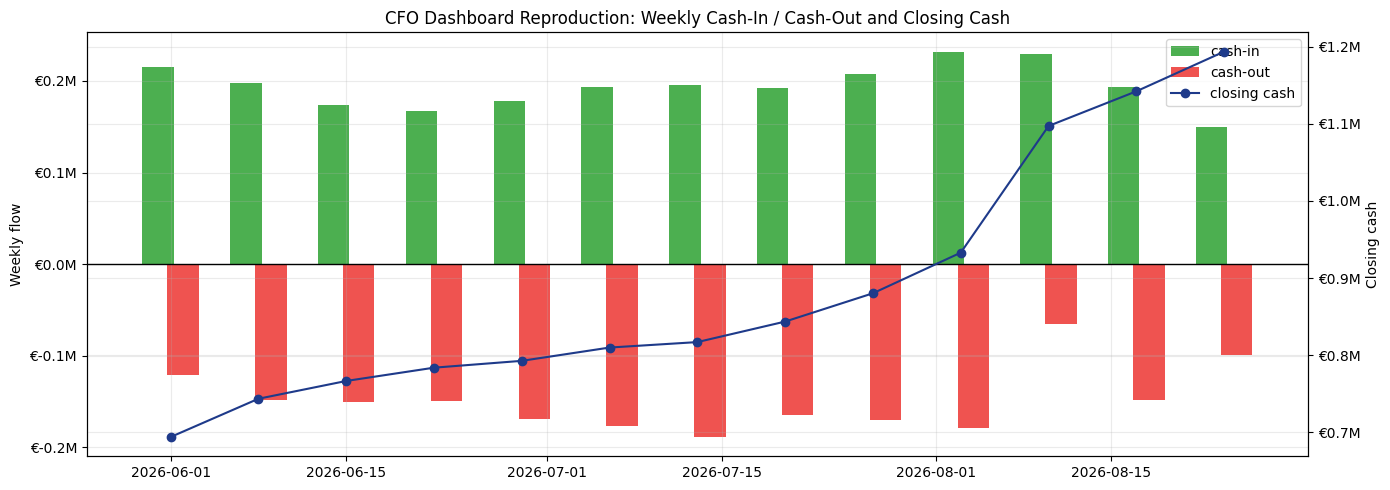

In [9]:
df = weeks_ummels.copy()
df["weekStartDt"] = pd.to_datetime(df["weekStart"])

fig, ax1 = plt.subplots(figsize=(14, 5))
ax1.bar(df["weekStartDt"] - pd.Timedelta(days=1), df["forecastCashIn"], width=2.5, label="cash-in", color="#4caf50")
ax1.bar(df["weekStartDt"] + pd.Timedelta(days=1), -df["forecastCashOut"], width=2.5, label="cash-out", color="#ef5350")
ax1.axhline(0, color="black", lw=1)
ax2 = ax1.twinx()
ax2.plot(df["weekStartDt"], df["closingCash"], color="#1e3a8a", marker="o", label="closing cash")
eur_axis(ax1)
eur_axis(ax2)
ax1.set_title("CFO Dashboard Reproduction: Weekly Cash-In / Cash-Out and Closing Cash")
ax1.set_ylabel("Weekly flow")
ax2.set_ylabel("Closing cash")
lines, labels = ax1.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
ax1.legend(lines + lines2, labels + labels2, loc="best")
plt.tight_layout()
plt.show()

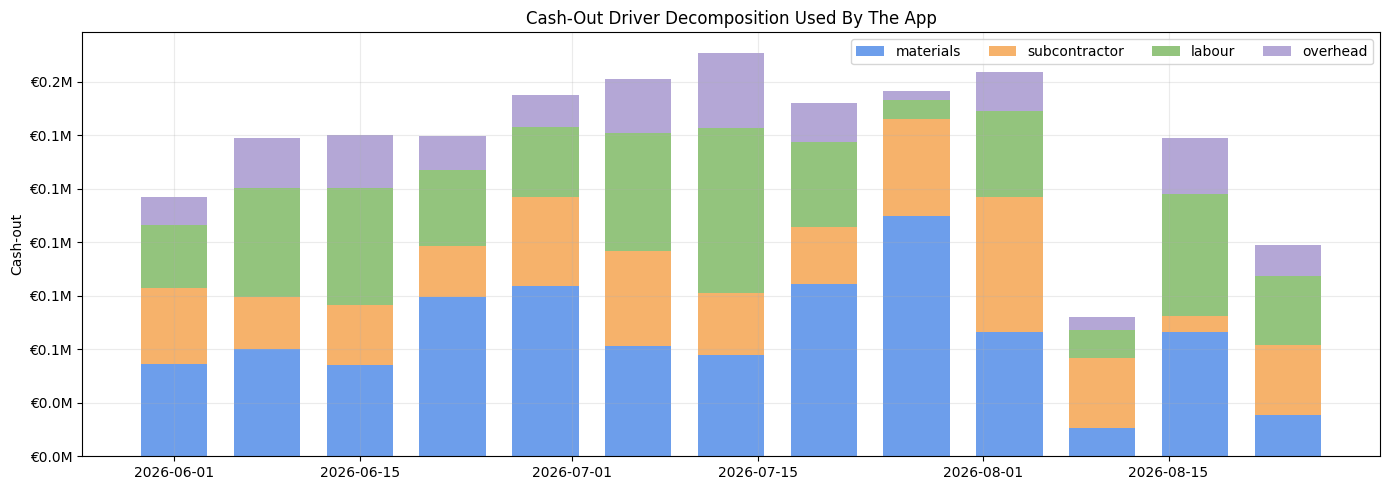

In [10]:
driver_cols = ["materials", "subcontractor", "labour", "overhead"]
fig, ax = plt.subplots(figsize=(14, 5))
bottom = np.zeros(len(df))
colors = ["#6d9eeb", "#f6b26b", "#93c47d", "#b4a7d6"]
for col, color in zip(driver_cols, colors):
    ax.bar(df["weekStartDt"], df[col], bottom=bottom, label=col, width=5, color=color)
    bottom += df[col].values
eur_axis(ax)
ax.set_title("Cash-Out Driver Decomposition Used By The App")
ax.set_ylabel("Cash-out")
ax.legend(ncol=4)
plt.tight_layout()
plt.show()

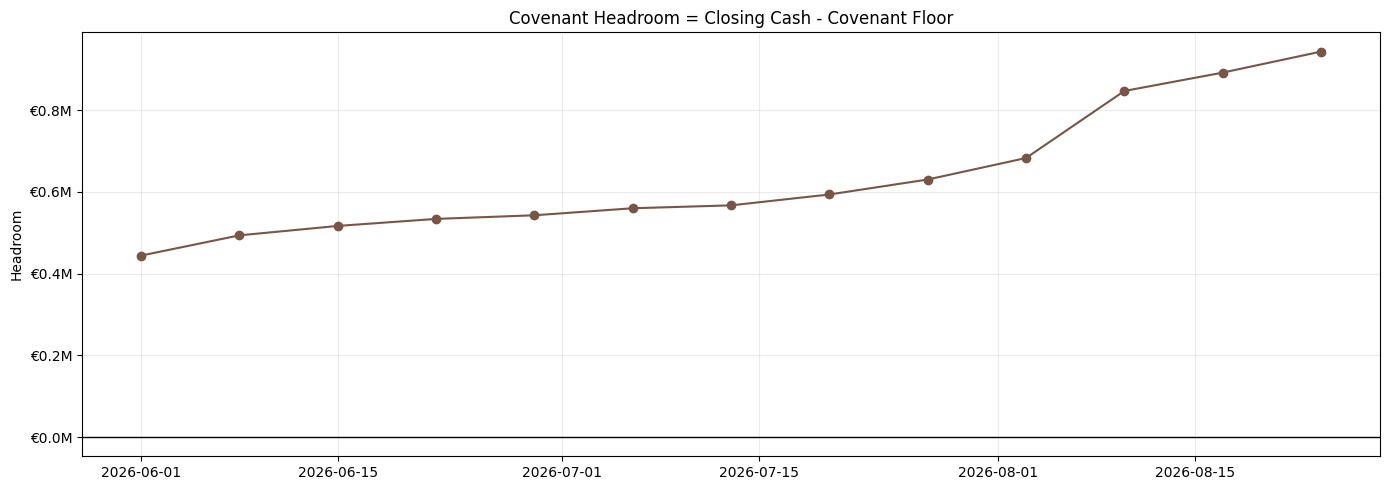

,weekStart,closingCash,covenantHeadroom,riskLevel,confidence
0,2026-06-01,694152,444152,medium,80
1,2026-06-08,743725,493725,low,88
2,2026-06-15,766770,516770,low,88
3,2026-06-22,783992,533992,low,68
4,2026-06-29,792858,542858,low,63
5,2026-07-06,810079,560079,low,62
6,2026-07-13,817162,567162,low,64
7,2026-07-20,843763,593763,medium,54
8,2026-07-27,880430,630430,medium,53
9,2026-08-03,933049,683049,low,56


In [11]:
fig, ax = plt.subplots(figsize=(14, 5))
ax.plot(df["weekStartDt"], df["covenantHeadroom"], marker="o", color="#795548")
ax.axhline(0, color="black", lw=1)
eur_axis(ax)
ax.set_title("Covenant Headroom = Closing Cash - Covenant Floor")
ax.set_ylabel("Headroom")
plt.tight_layout()
plt.show()

display(df[["weekStart", "closingCash", "covenantHeadroom", "riskLevel", "confidence"]])

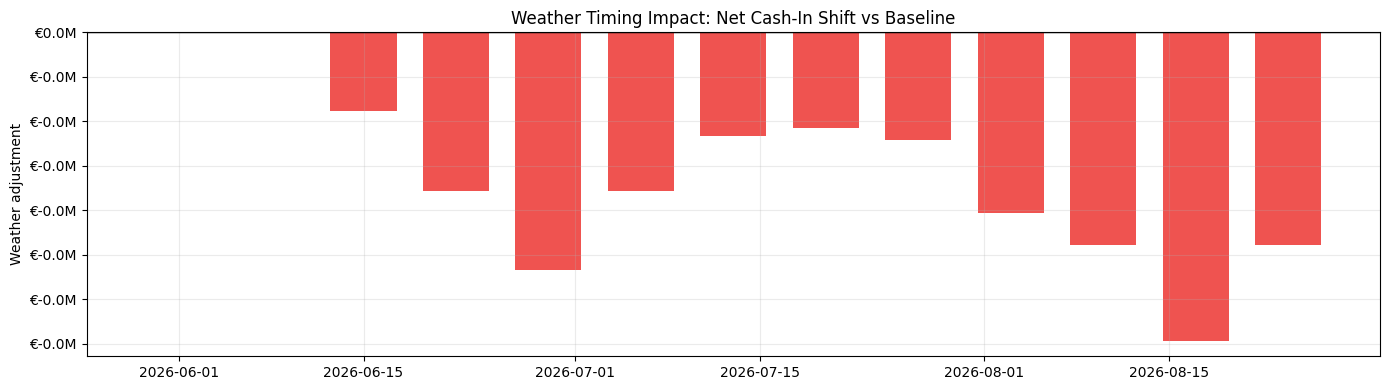

,weekStart,isLiveWeather,expectedRainWorkdays,weatherRisk,delayScore,weatherShiftOut,weatherAdjustment
0,2026-06-01,True,4.0,high,21.9,44499,0
1,2026-06-08,True,0.0,low,0.8,0,0
2,2026-06-15,True,0.0,low,0.0,0,-4450
3,2026-06-22,False,0.3,low,4.9,0,-8900
4,2026-06-29,False,2.3,medium,9.5,18422,-13350
5,2026-07-06,False,1.7,medium,9.6,32708,-8900
6,2026-07-13,False,1.0,low,4.8,0,-5847
7,2026-07-20,False,2.7,high,11.0,57664,-5398
8,2026-07-27,False,3.3,high,24.0,11851,-6061
9,2026-08-03,False,1.7,medium,9.6,22755,-10141


In [12]:
fig, ax = plt.subplots(figsize=(14, 4))
colors = df["weatherAdjustment"].apply(lambda x: "#ef5350" if x < 0 else "#4caf50")
ax.bar(df["weekStartDt"], df["weatherAdjustment"], color=colors, width=5)
ax.axhline(0, color="black", lw=1)
eur_smart_axis(ax)
ax.set_title("Weather Timing Impact: Net Cash-In Shift vs Baseline")
ax.set_ylabel("Weather adjustment")
for x, y in zip(df["weekStartDt"], df["weatherAdjustment"]):
    if abs(y) >= 500:
        ax.text(x, y, eur(y), ha="center", va="top" if y < 0 else "bottom", fontsize=8, rotation=90)
plt.tight_layout()
plt.show()

display(df[["weekStart", "isLiveWeather", "expectedRainWorkdays", "weatherRisk", "delayScore", "weatherShiftOut", "weatherAdjustment"]])

## 8. Trace One Week Like The App Drawer

Beginner explanation: choose a week and show exactly what supports it.

Technical explanation: this reconstructs the same evidence chain as `/api/trace`: forecast number, driver contribution, operational cause, scenario assumption, and source transactions from analog weeks.

In [13]:
TRACE_COMPANY = "ummels"
TRACE_SCENARIO = "base"
TRACE_WEEK = weeks_ummels.loc[1, "weekStart"]  # change this to inspect another week

trace_weeks, trace_kpis = compute_company_forecast(TRACE_COMPANY, TRACE_SCENARIO)
row = trace_weeks[trace_weeks["weekStart"] == TRACE_WEEK].iloc[0]
print("Trace week:", TRACE_WEEK)
display(pd.DataFrame([row]))

def analog_weeks(company_code, future_week, lookback=8):
    co = companies.loc[companies["code"] == company_code].iloc[0]
    hist = weekly[weekly["company_id"] == co["id"]].sort_values("week_start")
    woy = iso_week(future_week)
    same_woy = hist[hist["week_start"].apply(iso_week) == woy]["week_start"].tolist()
    recent = hist.tail(lookback)["week_start"].tolist()
    seen = []
    for x in same_woy + recent:
        if x not in seen:
            seen.append(x)
    return seen

analog = analog_weeks(TRACE_COMPANY, TRACE_WEEK)
co = companies.loc[companies["code"] == TRACE_COMPANY].iloc[0]
source_tx = transactions[(transactions["company_id"] == co["id"]) & (transactions["week_start"].isin(analog)) & (transactions["credit"] > 0)].copy()
source_tx = source_tx.sort_values("credit", ascending=False).head(12)
display(pd.DataFrame({"analogWeeks": analog}))
display(source_tx[["date", "week_start", "document_number", "journal", "account_code", "debit", "credit", "description"]])

Trace week: 2026-06-08


,company_code,company_name,scenario,weekIndex,weekStart,isLiveWeather,weatherSource,expectedRainWorkdays,weatherRisk,delayScore,...,labour,overhead,weatherAdjustment,paymentLagAdjustment,netCashFlow,closingCash,covenantHeadroom,riskLevel,confidence,weatherShiftOut
1,ummels,Peter Ummels,base,2,2026-06-08,True,live-forecast,0.0,low,0.8,...,51147,23249,0,-34196,49574,743725,493725,low,88,0


,analogWeeks
0,2023-06-12
1,2024-06-10
2,2025-06-09
3,2026-04-13
4,2026-04-20
5,2026-04-27
6,2026-05-04
7,2026-05-11
8,2026-05-18
9,2026-05-25


,date,week_start,document_number,journal,account_code,debit,credit,description
12877,2024-06-14,2024-06-10,2401238,80 - Verkoop,8005,0.0,108750.00,omzet waarbij de heffing naar u is verlegd
18703,2026-05-29,2026-05-25,260100326,80 - Verkoop,8005,0.0,86000.00,omzet waarbij de heffing naar u is verlegd
18704,2026-05-01,2026-04-27,260100213,80 - Verkoop,8005,0.0,83820.00,omzet waarbij de heffing naar u is verlegd
16224,2025-06-12,2025-06-09,250100061,80 - Verkoop,8005,0.0,71989.74,omzet waarbij de heffing naar u is verlegd
18706,2026-06-01,2026-06-01,260100347,80 - Verkoop,8005,0.0,69850.00,omzet waarbij de heffing naar u is verlegd
16240,2025-06-13,2025-06-09,250100072,80 - Verkoop,8005,0.0,60000.00,omzet waarbij de heffing naar u is verlegd
18709,2026-05-19,2026-05-18,260100285,80 - Verkoop,8005,0.0,55880.00,omzet waarbij de heffing naar u is verlegd
16266,2025-06-13,2025-06-09,250100069,80 - Verkoop,8005,0.0,48508.72,omzet waarbij de heffing naar u is verlegd
16270,2025-06-13,2025-06-09,250100068,80 - Verkoop,8005,0.0,47993.16,omzet waarbij de heffing naar u is verlegd
16288,2025-06-13,2025-06-09,250100066,80 - Verkoop,8005,0.0,45000.00,omzet waarbij de heffing naar u is verlegd


,driver,impact,evidence_type,reason
0,baseline_cash_in,198291,ledger history,8-week deseasonalised run-rate x ISO-week seas...
1,weather_delay,0,weather data / timing model,0.0 rain workdays -> low weather risk
2,payment_lag,-34196,assumption,cash collected differs from billed work; profi...
3,materials,-50019,assumption,"32% of production, paid approx. +2 weeks"
4,subcontractor,-24303,assumption,"18% of production, paid approx. +3 weeks"
5,labour,-51147,assumption,"22% of production, same week"
6,overhead,-23249,assumption,"10% of production, same week"


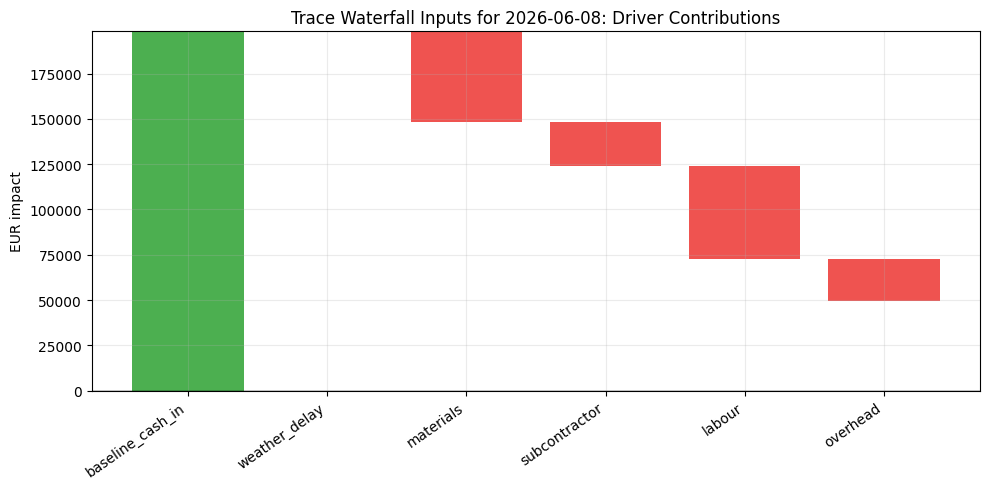

In [14]:
driver_trace = pd.DataFrame([
    {"driver": "baseline_cash_in", "impact": row["baselineCashIn"], "evidence_type": "ledger history", "reason": "8-week deseasonalised run-rate x ISO-week seasonality, then payment-lag profile"},
    {"driver": "weather_delay", "impact": row["weatherAdjustment"], "evidence_type": "weather data / timing model", "reason": f'{row["expectedRainWorkdays"]} rain workdays -> {row["weatherRisk"]} weather risk'},
    {"driver": "payment_lag", "impact": row["paymentLagAdjustment"], "evidence_type": "assumption", "reason": "cash collected differs from billed work; profile peaks around t+4"},
    {"driver": "materials", "impact": -row["materials"], "evidence_type": "assumption", "reason": "32% of production, paid approx. +2 weeks"},
    {"driver": "subcontractor", "impact": -row["subcontractor"], "evidence_type": "assumption", "reason": "18% of production, paid approx. +3 weeks"},
    {"driver": "labour", "impact": -row["labour"], "evidence_type": "assumption", "reason": "22% of production, same week"},
    {"driver": "overhead", "impact": -row["overhead"], "evidence_type": "assumption", "reason": "10% of production, same week"},
])
display(driver_trace)

fig, ax = plt.subplots(figsize=(10, 5))
waterfall = driver_trace[driver_trace["driver"] != "payment_lag"].copy()
waterfall = pd.concat([
    waterfall,
    pd.DataFrame([{"driver": "net_cash_flow", "impact": row["netCashFlow"], "evidence_type": "result", "reason": "cash-in minus cash-out after weather and driver timing"}]),
], ignore_index=True)
running = 0
for _, r in waterfall.iterrows():
    if r["driver"] == "net_cash_flow":
        bottom = 0
        height = r["impact"]
        color = "#263238" if r["impact"] >= 0 else "#8e0000"
    else:
        bottom = running if r["impact"] < 0 else 0
        height = r["impact"]
        color = "#4caf50" if r["impact"] >= 0 else "#ef5350"
        running += r["impact"]
    ax.bar(r["driver"], height, bottom=bottom, color=color)
    label_y = bottom + height
    ax.text(r["driver"], label_y, eur(r["impact"]), ha="center", va="bottom" if r["impact"] >= 0 else "top", fontsize=8, rotation=90)
ax.axhline(0, color="black", lw=1)
eur_smart_axis(ax)
ax.set_title(f"Trace Waterfall for {TRACE_WEEK}: Cash-In, Weather Timing, Cash-Out, Net")
ax.set_ylabel("EUR impact")
plt.xticks(rotation=35, ha="right")
plt.tight_layout()
plt.show()

## 9. Portfolio Calculation

Beginner explanation: the Board/CFO portfolio view sums company-level forecasts week by week.

Technical explanation: mirrors `computePortfolio`: sum cash-in, cash-out, drivers, closing cash, weather adjustment; use worst weather risk and portfolio liquidity covenant.

In [15]:
def risk_rank(r):
    return {"low": 0, "medium": 1, "high": 2}[r]

def compute_portfolio(scenario="base"):
    frames = []
    kpis = []
    for code in companies["code"]:
        if len(weekly[weekly["company_id"] == companies.loc[companies["code"] == code, "id"].iloc[0]]) == 0:
            continue
        f, k = compute_company_forecast(code, scenario)
        frames.append(f)
        k["company_code"] = code
        kpis.append(k)
    all_weeks = pd.concat(frames, ignore_index=True)
    rows = []
    portfolio_cov = covenants[covenants["metric"] == "min_13w_liquidity"]
    threshold = float(portfolio_cov["threshold"].iloc[0]) if len(portfolio_cov) else np.nan
    for week, g in all_weeks.groupby("weekStart", sort=True):
        closing = g["closingCash"].sum()
        headroom = closing - threshold if not np.isnan(threshold) else np.nan
        worst_wx = max(g["weatherRisk"], key=risk_rank)
        liq = "high" if not np.isnan(headroom) and headroom < 0 else "medium" if not np.isnan(headroom) and headroom < 0.25 * threshold else "low"
        final = ["low", "medium", "high"][max(risk_rank(liq), 1 if worst_wx == "high" else 0)]
        rows.append({
            "weekStart": week,
            "isLiveWeather": bool(g["isLiveWeather"].iloc[0]),
            "forecastCashIn": g["forecastCashIn"].sum(),
            "forecastCashOut": g["forecastCashOut"].sum(),
            "netCashFlow": g["netCashFlow"].sum(),
            "closingCash": closing,
            "covenantHeadroom": headroom,
            "weatherRisk": worst_wx,
            "riskLevel": final,
            "weatherAdjustment": g["weatherAdjustment"].sum(),
            "expectedRainWorkdays": g["expectedRainWorkdays"].max(),
            "confidence": round(g["confidence"].mean()),
        })
    portfolio = pd.DataFrame(rows).sort_values("weekStart")
    return portfolio, pd.DataFrame(kpis)

portfolio, company_kpis = compute_portfolio("base")
display(company_kpis)
display(portfolio)

,totalCashIn,totalCashOut,netCashFlow,minClosingCash,minClosingWeek,endingCash,weeksAtRisk,covenantBreach,liveWeatherWeeks,company_code
0,2525358,1931752,593606,694152,2026-06-01,1193605,3,False,3,ummels
1,3383676,2482537,901139,947981,2026-06-01,1801139,3,False,3,opco-a
2,2282255,1717870,564385,242019,2026-06-01,764385,3,False,3,opco-gilde
3,931560,696472,235088,178371,2026-06-01,355087,3,False,3,opco-e


,weekStart,isLiveWeather,forecastCashIn,forecastCashOut,netCashFlow,closingCash,covenantHeadroom,weatherRisk,riskLevel,weatherAdjustment,expectedRainWorkdays,confidence
0,2026-06-01,True,768655,526133,242523,2062523,1312523.0,high,medium,0,4.0,80
1,2026-06-08,True,713741,590574,123167,2185690,1435690.0,low,low,0,0.0,88
2,2026-06-15,True,701434,560482,140950,2326640,1576640.0,low,low,-18039,0.0,88
3,2026-06-22,False,663017,571069,91947,2418587,1668587.0,low,low,-36080,0.3,68
4,2026-06-29,False,674860,620012,54849,2473437,1723437.0,medium,low,-54119,2.3,63
5,2026-07-06,False,706417,648498,57919,2531355,1781355.0,medium,low,-36080,2.0,62
6,2026-07-13,False,741203,676442,64761,2596116,1846116.0,low,low,-24616,1.0,64
7,2026-07-20,False,742353,556816,185534,2781652,2031652.0,high,medium,-20775,3.3,54
8,2026-07-27,False,768100,559379,208721,2990372,2240372.0,high,medium,-21445,3.3,53
9,2026-08-03,False,790070,486840,303230,3293601,2543601.0,medium,low,-28275,1.7,56


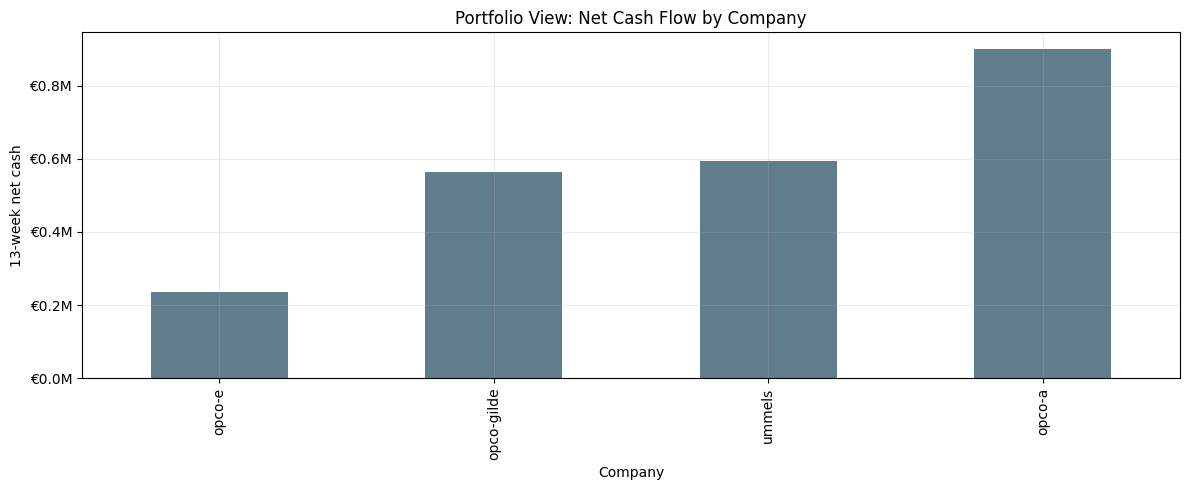

In [16]:
fig, ax = plt.subplots(figsize=(12, 5))
company_kpis.sort_values("netCashFlow").plot(x="company_code", y="netCashFlow", kind="bar", ax=ax, legend=False, color="#607d8b")
eur_axis(ax)
ax.set_title("Portfolio View: Net Cash Flow by Company")
ax.set_xlabel("Company")
ax.set_ylabel("13-week net cash")
plt.tight_layout()
plt.show()

## 10. CFO KPI Cards: Exact Evaluation From Forecast Weeks

This section is the direct proof for the CFO dashboard cards.

The app displays these KPI cards from `result.kpis`:

```text
Cash-in (13wk)      = sum(forecastCashIn over 13 weeks)
Cash-out (13wk)     = sum(forecastCashOut over 13 weeks)
Net cash (13wk)     = Cash-in - Cash-out
Min closing cash    = min(closingCash over 13 weeks)
Min closing week    = week where closingCash is lowest
Weeks at risk       = count(riskLevel != low)
Covenant breach     = any(covenantHeadroom < 0)
Live-weather weeks  = count(isLiveWeather)
```

In the codebase, these are evaluated in `lib/forecast/engine.ts::buildKpis` for single companies and in `lib/forecast/index.ts::computePortfolio` for the portfolio view.

In [17]:
def dashboard_kpis_from_weeks(weeks_df):
    return {
        "totalCashIn": int(round(weeks_df["forecastCashIn"].sum())),
        "totalCashOut": int(round(weeks_df["forecastCashOut"].sum())),
        "netCashFlow": int(round(weeks_df["forecastCashIn"].sum() - weeks_df["forecastCashOut"].sum())),
        "minClosingCash": int(round(weeks_df["closingCash"].min())),
        "minClosingWeek": weeks_df.loc[weeks_df["closingCash"].idxmin(), "weekStart"],
        "endingCash": int(round(weeks_df["closingCash"].iloc[-1])),
        "weeksAtRisk": int((weeks_df["riskLevel"] != "low").sum()),
        "covenantBreach": bool((weeks_df["covenantHeadroom"].dropna() < 0).any()),
        "liveWeatherWeeks": int(weeks_df["isLiveWeather"].sum()),
    }

all_company_rows = []
all_company_weeks = []
for code in companies["code"].tolist():
    company_id = companies.loc[companies["code"] == code, "id"].iloc[0]
    if len(weekly[weekly["company_id"] == company_id]) == 0:
        continue
    wk, _ = compute_company_forecast(code, "base")
    k = dashboard_kpis_from_weeks(wk)
    k["company_code"] = code
    k["company_name"] = wk["company_name"].iloc[0]
    all_company_rows.append(k)
    all_company_weeks.append(wk)

company_dashboard_kpis = pd.DataFrame(all_company_rows)
display(company_dashboard_kpis[[
    "company_code", "company_name", "totalCashIn", "totalCashOut", "netCashFlow",
    "minClosingCash", "minClosingWeek", "endingCash", "weeksAtRisk", "covenantBreach",
    "liveWeatherWeeks"
]])

,company_code,company_name,totalCashIn,totalCashOut,netCashFlow,minClosingCash,minClosingWeek,endingCash,weeksAtRisk,covenantBreach,liveWeatherWeeks
0,ummels,Peter Ummels,2525358,1931752,593606,694152,2026-06-01,1193605,3,False,3
1,opco-a,Opco A,3383676,2482537,901139,947981,2026-06-01,1801139,3,False,3
2,opco-gilde,Opco C,2282255,1717870,564385,242019,2026-06-01,764385,3,False,3
3,opco-e,Company E,931560,696472,235088,178371,2026-06-01,355087,3,False,3


In [18]:
# Portfolio dashboard KPIs are not calculated from raw transactions directly.
# They are calculated by first forecasting each company, then summing week by week.
portfolio_weeks, _company_kpis = compute_portfolio("base")

portfolio_dashboard_kpis = {
    "scope": "portfolio",
    "totalCashIn": int(round(portfolio_weeks["forecastCashIn"].sum())),
    "totalCashOut": int(round(portfolio_weeks["forecastCashOut"].sum())),
    "netCashFlow": int(round(portfolio_weeks["netCashFlow"].sum())),
    "minClosingCash": int(round(portfolio_weeks["closingCash"].min())),
    "minClosingWeek": portfolio_weeks.loc[portfolio_weeks["closingCash"].idxmin(), "weekStart"],
    "endingCash": int(round(portfolio_weeks["closingCash"].iloc[-1])),
    "weeksAtRisk": int((portfolio_weeks["riskLevel"] != "low").sum()),
    "covenantBreach": bool((portfolio_weeks["covenantHeadroom"].dropna() < 0).any()),
    "liveWeatherWeeks": int(portfolio_weeks["isLiveWeather"].sum()),
}
display(pd.DataFrame([portfolio_dashboard_kpis]))

print("Important interpretation:")
print("- Portfolio cash-in/out = sum of company forecast cash-in/out by week.")
print("- Portfolio closing cash = sum of company closing cash by week.")
print("- Portfolio min closing cash is the minimum of that portfolio weekly closing-cash line.")

,scope,totalCashIn,totalCashOut,netCashFlow,minClosingCash,minClosingWeek,endingCash,weeksAtRisk,covenantBreach,liveWeatherWeeks
0,portfolio,9122849,6828631,2294215,2062523,2026-06-01,4114216,3,False,3


Important interpretation:
- Portfolio cash-in/out = sum of company forecast cash-in/out by week.
- Portfolio closing cash = sum of company closing cash by week.
- Portfolio min closing cash is the minimum of that portfolio weekly closing-cash line.


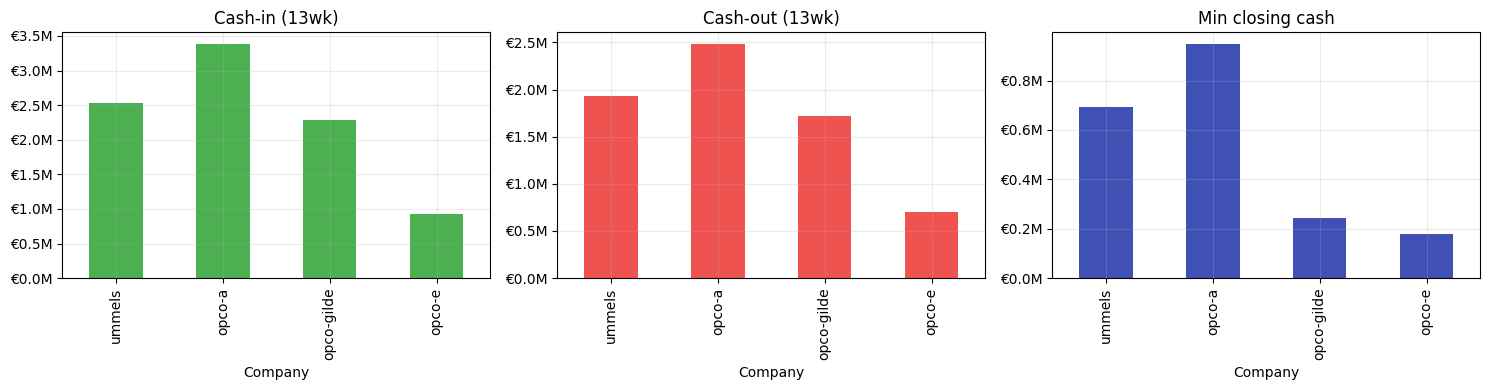

In [19]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4))
company_dashboard_kpis.plot(x="company_code", y="totalCashIn", kind="bar", ax=axes[0], legend=False, color="#4caf50")
company_dashboard_kpis.plot(x="company_code", y="totalCashOut", kind="bar", ax=axes[1], legend=False, color="#ef5350")
company_dashboard_kpis.plot(x="company_code", y="minClosingCash", kind="bar", ax=axes[2], legend=False, color="#3f51b5")
for ax, title in zip(axes, ["Cash-in (13wk)", "Cash-out (13wk)", "Min closing cash"]):
    eur_axis(ax)
    ax.set_title(title)
    ax.set_xlabel("Company")
plt.tight_layout()
plt.show()

In [20]:
# Show the actual 13 rows that feed the CFO cashflow chart for the selected company.
cfo_scope = "ummels"  # change to opco-a, opco-gilde, opco-e, or use portfolio_weeks above
cfo_weeks, _ = compute_company_forecast(cfo_scope, "base")
display(cfo_weeks[[
    "weekIndex", "weekStart", "forecastCashIn", "forecastCashOut", "netCashFlow",
    "closingCash", "covenantHeadroom", "weatherRisk", "riskLevel", "confidence"
]])

print("These 13 rows are exactly what the CFO chart/table summarizes for", cfo_scope)

,weekIndex,weekStart,forecastCashIn,forecastCashOut,netCashFlow,closingCash,covenantHeadroom,weatherRisk,riskLevel,confidence
0,1,2026-06-01,215462,121311,94152,694152,444152,high,medium,80
1,2,2026-06-08,198291,148718,49574,743725,493725,low,low,88
2,3,2026-06-15,173385,150339,23045,766770,516770,low,low,88
3,4,2026-06-22,166968,149746,17222,783992,533992,low,low,68
4,5,2026-06-29,177701,168835,8866,792858,542858,medium,low,63
5,6,2026-07-06,193567,176346,17221,810079,560079,medium,low,62
6,7,2026-07-13,195820,188737,7083,817162,567162,low,low,64
7,8,2026-07-20,191842,165240,26601,843763,593763,high,medium,54
8,9,2026-07-27,207357,170690,36667,880430,630430,high,medium,53
9,10,2026-08-03,232042,179423,52619,933049,683049,medium,low,56


These 13 rows are exactly what the CFO chart/table summarizes for ummels


## 11. Risk Overview: Reproduce The Eight App Risk Cards

The current app has a **Risk overview — weather-to-cash** card. It is rendered by `components/RiskOverview.tsx` and populated from `/api/risks`.

This section reproduces those eight app risk signals:

1. Weather Billing Risk
2. Cash-In Delay Risk
3. Payment Terms Risk
4. Cash-Out Assumption Risk
5. Covenant Headroom Risk
6. Data Quality Risk
7. Forecast Confidence Risk
8. Opco Underperformance Risk

The formulas mirror `lib/forecast/risks.ts`.

In [21]:
LAG_PROFILE = (
    "Rain workdays t→t+3 ≈ −12pp, t+4 ≈ +16pp catch-up, t+5 ≈ −7pp, t+6 ≈ −10pp; "
    "rainfall total t+1 ≈ −15pp, t+3 ≈ −18pp, t+4 ≈ +9pp, t+5/6 ≈ −16pp. "
    "Suggestive signal, not causal (p≈0.07–0.19)."
)

def worse(a, b):
    order = ["low", "medium", "high"]
    return a if order.index(a) >= order.index(b) else b

def pct_text(x):
    return f"{x * 100:.0f}%"

def shifted_payment_profile_plus_2():
    return [0, 0] + DEFAULT_PARAMS["paymentLagWeights"]

def compute_company_forecast_with_overrides(company_code="ummels", scenario="base", payment_lag_weights=None):
    original = DEFAULT_PARAMS["paymentLagWeights"]
    if payment_lag_weights is not None:
        DEFAULT_PARAMS["paymentLagWeights"] = payment_lag_weights
    try:
        return compute_company_forecast(company_code, scenario)
    finally:
        DEFAULT_PARAMS["paymentLagWeights"] = original

def mean_list(xs):
    xs = list(xs)
    return sum(xs) / len(xs) if xs else 0

In [22]:
def risk_context(company_code="ummels", scenario="base"):
    is_portfolio = company_code == "portfolio"
    if is_portfolio:
        result_weeks, company_kpis_local = compute_portfolio(scenario)
        stress_frames = []
        for code in companies["code"].tolist():
            company_id = companies.loc[companies["code"] == code, "id"].iloc[0]
            if len(weekly[weekly["company_id"] == company_id]) == 0:
                continue
            wk, _ = compute_company_forecast_with_overrides(code, scenario, shifted_payment_profile_plus_2())
            stress_frames.append(wk)
        stress_all = pd.concat(stress_frames, ignore_index=True)
        stress_cash_in = stress_all.groupby("weekStart")["forecastCashIn"].sum().sum()
        cohort_codes = companies["code"].tolist()
        threshold_row = covenants[covenants["metric"] == "min_13w_liquidity"]
        threshold = float(threshold_row["threshold"].iloc[0]) if len(threshold_row) else np.nan
    else:
        result_weeks, _ = compute_company_forecast(company_code, scenario)
        stress_weeks, _ = compute_company_forecast_with_overrides(company_code, scenario, shifted_payment_profile_plus_2())
        stress_cash_in = stress_weeks["forecastCashIn"].sum()
        cohort_codes = [company_code]
        co_id = companies.loc[companies["code"] == company_code, "id"].iloc[0]
        threshold_row = covenants[(covenants["metric"] == "min_cash_balance") & (covenants["company_id"] == co_id)]
        threshold = float(threshold_row["threshold"].iloc[0]) if len(threshold_row) else np.nan

    # Reconciliation variance from data_inventory.json
    inv_path = ART / "data_inventory.json"
    recon_worst = None
    if inv_path.exists():
        inv = json.loads(inv_path.read_text())
        recon = pd.DataFrame(inv.get("reconciliation", []))
        if len(recon):
            if not is_portfolio:
                co_id = companies.loc[companies["code"] == company_code, "id"].iloc[0]
                recon = recon[recon["company_id"] == co_id]
            recon = recon.dropna(subset=["monthly_summary_netto"])
            if len(recon):
                variances = (recon["weekly_credit_total"] - recon["monthly_summary_netto"]) / recon["monthly_summary_netto"]
                recon_worst = variances.iloc[np.argmax(np.abs(variances.values))]

    # Underperformance and thin history
    underperformers = []
    thin_history = False
    for code in cohort_codes:
        if code not in companies["code"].values:
            continue
        co = companies.loc[companies["code"] == code].iloc[0]
        h = weekly[weekly["company_id"] == co["id"]].sort_values("week_start")
        if len(h) < 26:
            thin_history = True
            continue
        recent = h.tail(8)["credit_total"].mean()
        prior = h.tail(26).head(18)["credit_total"].mean()
        if prior > 0:
            pct_under = (recent - prior) / prior
            if pct_under < -0.03:
                underperformers.append({"name": co["short_name"], "pct": pct_under, "eur": (recent - prior) * 13})

    return {
        "weeks": result_weeks,
        "threshold": threshold,
        "driverTotalPct": sum(DEFAULT_PARAMS["drivers"].values()),
        "paymentStressCashIn": stress_cash_in,
        "reconWorstVariancePct": recon_worst,
        "thinHistory": thin_history,
        "underperformers": underperformers,
    }

In [23]:
def compute_risk_signals_notebook(company_code="ummels", scenario="base"):
    ctx = risk_context(company_code, scenario)
    weeks = ctx["weeks"].copy()
    k = dashboard_kpis_from_weeks(weeks)
    mean_conf = round(weeks["confidence"].mean())
    threshold = ctx["threshold"]

    rows = []

    # 1 Weather Billing Risk
    wx_weeks = weeks[weeks["weatherRisk"] != "low"]
    wx_high = weeks[weeks["weatherRisk"] == "high"]
    wx_impact = wx_weeks["weatherAdjustment"].abs().sum()
    rows.append({
        "key": "weather_billing",
        "title": "Weather Billing Risk",
        "level": "high" if len(wx_high) else "medium" if len(wx_weeks) else "low",
        "eurImpact": round(wx_impact),
        "confidence": 70 if ((weeks["weatherRisk"] != "low") & (weeks["isLiveWeather"])).any() else 55,
        "impactedWeeks": ", ".join(wx_weeks["weekStart"].tolist()),
        "reason": f"{len(wx_weeks)} of 13 weeks carry weather-delay risk ({len(wx_high)} high). ≈ {eur(wx_impact)} of billing is shifted later in those weeks.",
        "trace": "weather_weekly rain workdays → billing timing shift. " + LAG_PROFILE,
    })

    # 2 Cash-In Delay Risk
    early_deferred = weeks.head(4)["paymentLagAdjustment"].apply(lambda x: max(0, -x)).sum()
    rows.append({
        "key": "cash_in_delay",
        "title": "Cash-In Delay Risk",
        "level": "medium" if early_deferred > 0.4 * (k["totalCashIn"] / 13) * 4 else "low",
        "eurImpact": round(early_deferred),
        "confidence": 65,
        "impactedWeeks": ", ".join(weeks.head(4)["weekStart"].tolist()),
        "reason": f"Cash-in lags billing by ~4 weeks: ≈ {eur(early_deferred)} billed in weeks 1-4 collects later in the horizon.",
        "trace": "Assumption: debtor-payment profile, mean ≈ 4 weeks.",
    })

    # 3 Payment Terms Risk
    terms_mag = abs(k["totalCashIn"] - ctx["paymentStressCashIn"])
    terms_level = "high" if terms_mag > 0.07 * k["totalCashIn"] else "medium" if terms_mag > 0.03 * k["totalCashIn"] else "low"
    rows.append({
        "key": "payment_terms",
        "title": "Payment Terms Risk",
        "level": terms_level,
        "eurImpact": round(terms_mag),
        "confidence": 55,
        "impactedWeeks": "",
        "reason": f"A ~2-week change in debtor days moves in-horizon cash-in by ≈ {eur(terms_mag)}.",
        "trace": "Assumption sensitivity: payment-lag profile shifted +2 weeks.",
    })

    # 4 Cash-Out Assumption Risk
    rows.append({
        "key": "cash_out_assumption",
        "title": "Cash-Out Assumption Risk",
        "level": "high",
        "eurImpact": round(k["totalCashOut"]),
        "confidence": 45,
        "impactedWeeks": ", ".join(weeks["weekStart"].tolist()),
        "reason": f"All cash-out ({eur(k['totalCashOut'])} over 13 wks) is modelled from driver % assumptions ({pct_text(ctx['driverTotalPct'])} of production).",
        "trace": "Assumptions: materials/subcontractor/labour/overhead shares. No AP/cost ledger in source data.",
    })

    # 5 Covenant Headroom Risk
    headrooms = weeks["covenantHeadroom"].dropna()
    min_headroom = headrooms.min() if len(headrooms) else np.nan
    tight = weeks[weeks["covenantHeadroom"].fillna(np.inf) < 0.25 * threshold] if not pd.isna(threshold) else pd.DataFrame()
    level = "high" if k["covenantBreach"] else "medium" if len(tight) else "low"
    rows.append({
        "key": "covenant_headroom",
        "title": "Covenant Headroom Risk",
        "level": level,
        "eurImpact": round(min_headroom) if not pd.isna(min_headroom) else None,
        "confidence": 60,
        "impactedWeeks": ", ".join(tight["weekStart"].tolist()) if len(tight) else "",
        "reason": "No covenant floor configured." if pd.isna(threshold) else f"Minimum headroom {eur(min_headroom)} vs {eur(threshold)} floor.",
        "trace": "Assumption: covenant floor + opening cash; no bank balances in source data.",
    })

    # 6 Data Quality Risk
    v = ctx["reconWorstVariancePct"]
    dq_level = "medium" if v is None else "high" if abs(v) > 0.2 else "medium" if abs(v) > 0.05 else "low"
    dq_level = worse(dq_level, "medium")
    rows.append({
        "key": "data_quality",
        "title": "Data Quality Risk",
        "level": dq_level,
        "eurImpact": None,
        "confidence": 60,
        "impactedWeeks": "",
        "reason": "Source is billing/revenue only. " + ("Only Opco A has monthly summary reconciliation." if v is None else f"Worst reconciliation variance ≈ {pct_text(abs(v))}."),
        "trace": "data_inventory reconciliation + missing-fields list.",
    })

    # 7 Forecast Confidence Risk
    conf_level = "high" if mean_conf < 60 else "medium" if mean_conf < 72 else "low"
    conf_level = worse(conf_level, "medium" if ctx["thinHistory"] else "low")
    low_conf_weeks = weeks[weeks["confidence"] < 65]
    live_weeks = int(weeks["isLiveWeather"].sum())
    rows.append({
        "key": "forecast_confidence",
        "title": "Forecast Confidence Risk",
        "level": conf_level,
        "eurImpact": None,
        "confidence": mean_conf,
        "impactedWeeks": ", ".join(low_conf_weeks["weekStart"].tolist()),
        "reason": f"Mean weekly confidence {mean_conf}%. Weeks 1-{live_weeks} use live Open-Meteo; later weeks use seasonal climatology.",
        "trace": "Live-vs-seasonal weather split + history depth.",
    })

    # 8 Opco Underperformance Risk
    under = ctx["underperformers"]
    worst_under = min([u["pct"] for u in under], default=0)
    rows.append({
        "key": "opco_underperformance",
        "title": "Opco Underperformance Risk",
        "level": "high" if worst_under < -0.15 else "medium" if worst_under < -0.08 else "low",
        "eurImpact": round(sum(u["eur"] for u in under)) if under else None,
        "confidence": 65,
        "impactedWeeks": "",
        "reason": ", ".join([f"{u['name']} {pct_text(u['pct'])}" for u in under]) + " running below recent run-rate." if under else "Recent run-rate in line with prior periods.",
        "trace": "Last-8-week actual facturation vs prior 18 weeks.",
    })
    return pd.DataFrame(rows)

risk_scope = "ummels"  # change to "portfolio" to reproduce the Board/CFO portfolio risk overview
risk_overview = compute_risk_signals_notebook(risk_scope, "base")
display(risk_overview[["title", "level", "eurImpact", "confidence", "reason", "trace"]])

,title,level,eurImpact,confidence,reason,trace
0,Weather Billing Risk,high,55786.0,70,7 of 13 weeks carry weather-delay risk (3 high...,weather_weekly rain workdays → billing timing ...
1,Cash-In Delay Risk,low,109201.0,65,"Cash-in lags billing by ~4 weeks: ≈ €109,201 b...","Assumption: debtor-payment profile, mean ≈ 4 w..."
2,Payment Terms Risk,medium,79370.0,55,A ~2-week change in debtor days moves in-horiz...,Assumption sensitivity: payment-lag profile sh...
3,Cash-Out Assumption Risk,high,1931752.0,45,"All cash-out (€1,931,752 over 13 wks) is model...",Assumptions: materials/subcontractor/labour/ov...
4,Covenant Headroom Risk,low,444152.0,60,"Minimum headroom €444,152 vs €250,000 floor.",Assumption: covenant floor + opening cash; no ...
5,Data Quality Risk,medium,NaN,60,Source is billing/revenue only. Only Opco A ha...,data_inventory reconciliation + missing-fields...
6,Forecast Confidence Risk,medium,NaN,65,Mean weekly confidence 65%. Weeks 1-3 use live...,Live-vs-seasonal weather split + history depth.
7,Opco Underperformance Risk,low,NaN,65,Recent run-rate in line with prior periods.,Last-8-week actual facturation vs prior 18 weeks.


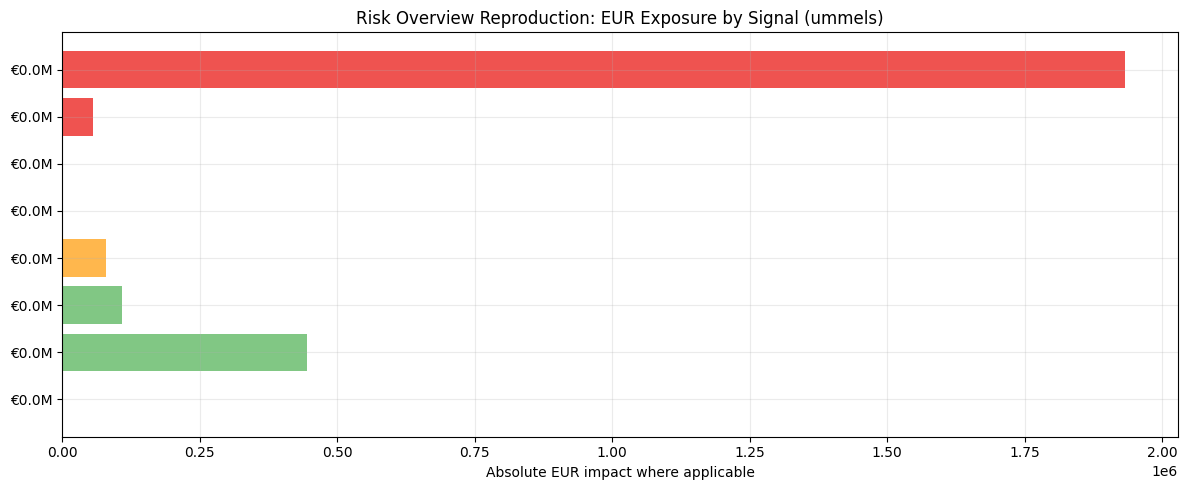

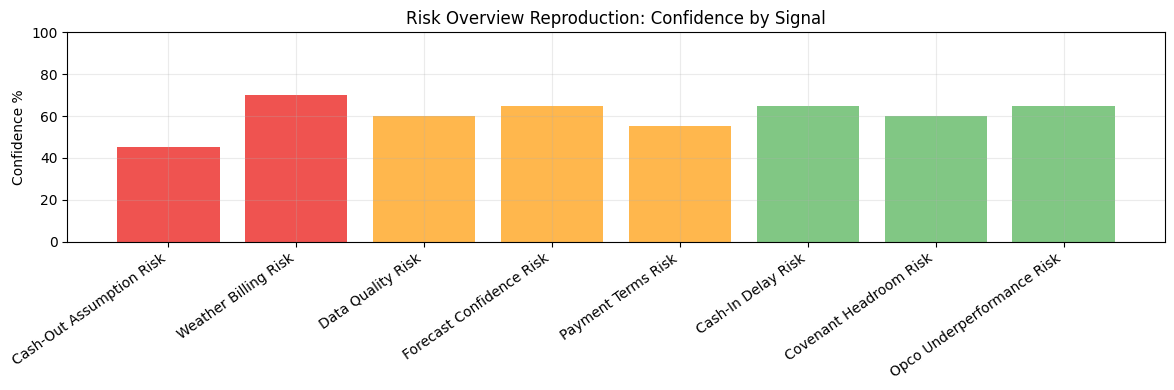

In [24]:
level_order = {"high": 0, "medium": 1, "low": 2}
plot_risks = risk_overview.copy()
plot_risks["sort"] = plot_risks["level"].map(level_order)
plot_risks = plot_risks.sort_values(["sort", "title"])
colors = plot_risks["level"].map({"high": "#ef5350", "medium": "#ffb74d", "low": "#81c784"})

fig, ax = plt.subplots(figsize=(12, 5))
impact = plot_risks["eurImpact"].fillna(0).abs()
ax.barh(plot_risks["title"], impact, color=colors)
eur_axis(ax)
ax.set_title(f"Risk Overview Reproduction: EUR Exposure by Signal ({risk_scope})")
ax.set_xlabel("Absolute EUR impact where applicable")
ax.invert_yaxis()
plt.tight_layout()
plt.show()

fig, ax = plt.subplots(figsize=(12, 4))
ax.bar(plot_risks["title"], plot_risks["confidence"], color=colors)
ax.set_ylim(0, 100)
ax.set_title("Risk Overview Reproduction: Confidence by Signal")
ax.set_ylabel("Confidence %")
plt.xticks(rotation=35, ha="right")
plt.tight_layout()
plt.show()

## 12. Analyst Takeaways

Use this notebook to show the CFO/controller:

```text
1. Which raw Excel files exist.
2. How those files become normalized tables.
3. How the app's exact forecast math is calculated.
4. How notebook output compares with the running app API.
5. Which source transactions support a selected week.
6. Which inputs are observed vs inferred vs assumed.
```